In [1]:
import pandas as pd
import os
import numpy as np
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parents[0]
DATASET_ROOT = PROJECT_ROOT / "data"
ORIGINAL_ROOT = DATASET_ROOT / "original"
CONVERSION_ROOT = DATASET_ROOT / "conversion"

os.chdir(PROJECT_ROOT) # 현재 경로 수정
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/mungughyeon/Documents/internship/Likelion/drowsiness_detection


In [2]:
from src.utils.video_conversion import extract_frames_video

# 이탈 영상
extract_frames_video(
    video_path=ORIGINAL_ROOT / "이탈 영상" / "kdt-backendj-19th_z6q0fy_2025-10-13-08-47-32.mp4",
    output_dir=CONVERSION_ROOT / "이탈 영상",
    interval_sec=1
)

총 5396개의 프레임 저장


In [2]:
from src.utils.video_conversion import extract_frames_from_folder

# 수강생 녹화 영상
extract_frames_from_folder(
    input_dir=ORIGINAL_ROOT / "수강생 녹화 영상",
    output_root=CONVERSION_ROOT / "수강생 녹화 영상",
    interval_sec=1
)

Processing: kdt-backendj-19th_rsmnql_2025-10-14-08-56-24.mp4
총 5396개의 프레임 저장
Processing: kdt-backendj-19th_33sxox_2025-11-17-09-03-57.mp4
총 5394개의 프레임 저장
Processing: kdt-backendj-19th_4xvjn2_2025-11-05-08-54-12.mp4
총 5396개의 프레임 저장
Processing: kdt-backendj-19th_oxuogm_2025-10-27-08-57-11.mp4
총 6062개의 프레임 저장
Processing: kdt-backendj-19th_vjdppt_2025-11-19-08-57-19.mp4
총 3391개의 프레임 저장
Processing: kdt-backendj-19th_qhwzp8_2025-11-11-09-03-38.mp4
총 5393개의 프레임 저장
Processing: kdt-backendj-19th_xr3l3i_2025-10-23-08-56-57.mp4
총 5396개의 프레임 저장
Processing: kdt-backendj-19th_c7hwgw_2025-10-22-08-41-02.mp4
총 4625개의 프레임 저장
Processing: kdt-backendj-19th_ifdu5n_2025-11-18-08-53-34.mp4
총 5076개의 프레임 저장
Processing: kdt-backendj-19th_kwwb8h_2025-10-21-09-00-57.mp4
총 5395개의 프레임 저장


## Data info

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.dataset.data_loader import load_dataset

summary = load_dataset(CONVERSION_ROOT)

# create data info 
rows = []
for v in summary.all_videos:
    rows.append({
        "video_id": v.video_id,
        "date": v.date,
        "label": v.label,
        "frame_count": v.frame_count,
        "path": v.frame_dir.relative_to(PROJECT_ROOT),
    })
info_df = pd.DataFrame(rows)
info_df

,video_id,date,label,frame_count,path
0,33sxox,2025-11-17,normal,5394,data/conversion/수강생 녹화 영상/kdt-backendj-19th_33...
1,4xvjn2,2025-11-05,normal,5396,data/conversion/수강생 녹화 영상/kdt-backendj-19th_4x...
2,c7hwgw,2025-10-22,normal,4625,data/conversion/수강생 녹화 영상/kdt-backendj-19th_c7...
3,ifdu5n,2025-11-18,normal,5076,data/conversion/수강생 녹화 영상/kdt-backendj-19th_if...
4,kwwb8h,2025-10-21,normal,5395,data/conversion/수강생 녹화 영상/kdt-backendj-19th_kw...
5,oxuogm,2025-10-27,normal,6062,data/conversion/수강생 녹화 영상/kdt-backendj-19th_ox...
6,qhwzp8,2025-11-11,normal,5393,data/conversion/수강생 녹화 영상/kdt-backendj-19th_qh...
7,rsmnql,2025-10-14,normal,5396,data/conversion/수강생 녹화 영상/kdt-backendj-19th_rs...
8,vjdppt,2025-11-19,normal,3391,data/conversion/수강생 녹화 영상/kdt-backendj-19th_vj...
9,xr3l3i,2025-10-23,normal,5396,data/conversion/수강생 녹화 영상/kdt-backendj-19th_xr...


In [3]:
import cv2
from tqdm import tqdm
from datetime import timedelta

def collect_all_frame_stats(video_info, pbar) -> list[dict]:
    """영상 폴더의 모든 프레임에 대해 행 1개씩 통계 반환."""
    frame_files = sorted(
        video_info.frame_dir.glob("frame_*.jpg"),
        key=lambda p: int(p.stem.split("_")[1])
    )

    rows = []
    for fp in frame_files:
        img = cv2.imread(str(fp))
        if img is None:
            pbar.update(1)
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = img.shape[:2]

        sec = int(fp.stem.split("_")[1])
        datetime = video_info.start_time + timedelta(seconds=sec)

        rows.append({
            "video_id": video_info.video_id,
            "frame_id": fp.stem,
            "datetime": datetime,
            "label": video_info.label,
            "width": w,
            "height": h,
            "brightness": round(float(gray.mean()), 2),
            "r_mean": round(float(img_rgb[:, :, 0].mean()), 2),
            "g_mean": round(float(img_rgb[:, :, 1].mean()), 2),
            "b_mean": round(float(img_rgb[:, :, 2].mean()), 2),
            "r_std": round(float(img_rgb[:, :, 0].std()), 2),
            "g_std": round(float(img_rgb[:, :, 1].std()), 2),
            "b_std": round(float(img_rgb[:, :, 2].std()), 2),
        })
        pbar.update(1)
    return rows

total_frames = sum(v.frame_count for v in summary.all_videos)
all_rows = []
with tqdm(total=total_frames, desc="frames", unit="f") as pbar:
    for v in summary.all_videos:
        pbar.set_postfix(video=v.video_id)
        all_rows.extend(collect_all_frame_stats(v, pbar))

frame_df = pd.DataFrame(all_rows)
if not (CONVERSION_ROOT / "frame_stats.csv").exists():
    frame_df.to_csv(CONVERSION_ROOT / "frame_stats.csv", index=False) # save

frame_df

frames:   0%|          | 0/56920 [00:00<?, ?f/s, video=33sxox]

frames: 100%|██████████| 56920/56920 [06:52<00:00, 138.12f/s, video=z6q0fy]


,video_id,frame_id,datetime,label,width,height,brightness,r_mean,g_mean,b_mean,r_std,g_std,b_std
0,33sxox,frame_0,2025-11-17 09:03:57,normal,1280,720,11.10,13.45,9.68,12.32,39.55,25.98,33.75
1,33sxox,frame_1,2025-11-17 09:03:58,normal,1280,720,6.86,6.95,6.76,7.14,23.62,20.10,22.76
2,33sxox,frame_2,2025-11-17 09:03:59,normal,1280,720,8.70,8.67,8.69,8.87,30.59,30.35,30.97
3,33sxox,frame_3,2025-11-17 09:04:00,normal,1280,720,8.68,8.63,8.68,8.86,30.47,30.34,30.98
4,33sxox,frame_4,2025-11-17 09:04:01,normal,1280,720,8.68,8.63,8.67,8.86,30.48,30.33,30.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56915,z6q0fy,frame_5391,2025-10-13 10:17:23,escape,1280,720,207.29,207.44,206.73,209.72,71.78,72.23,69.72
56916,z6q0fy,frame_5392,2025-10-13 10:17:24,escape,1280,720,207.29,207.45,206.73,209.72,71.77,72.24,69.72
56917,z6q0fy,frame_5393,2025-10-13 10:17:25,escape,1280,720,207.23,207.40,206.67,209.65,71.84,72.33,69.84
56918,z6q0fy,frame_5394,2025-10-13 10:17:26,escape,1280,720,207.26,207.43,206.70,209.66,71.79,72.29,69.82


## Frame count

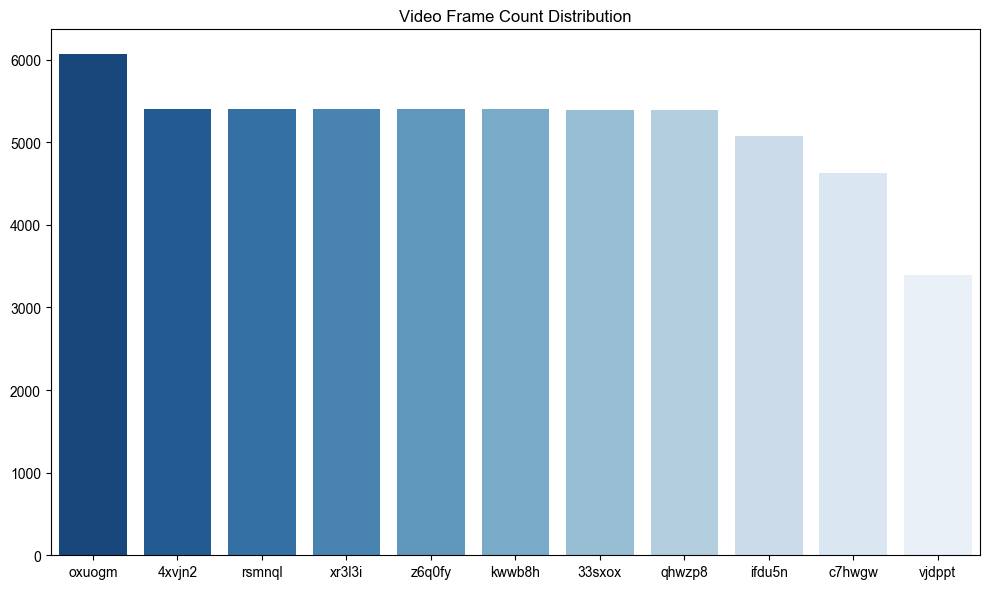

,frame_count
count,11.000000
mean,5174.545455
std,679.777370
min,3391.000000
25%,5234.500000
50%,5395.000000
75%,5396.000000
max,6062.000000


In [3]:
from src.visual.plot import *

set_korean_font(verbose=False) # verbose=True: message 출력
bar_plot(
    df=info_df.sort_values(by=['frame_count'], ascending=False),
    figsize=(10, 6),
    x_col='video_id',
    y_col='frame_count',
    title='Video Frame Count Distribution'
)

info_df[['frame_count']].describe()

## Brightness & RGB chanel

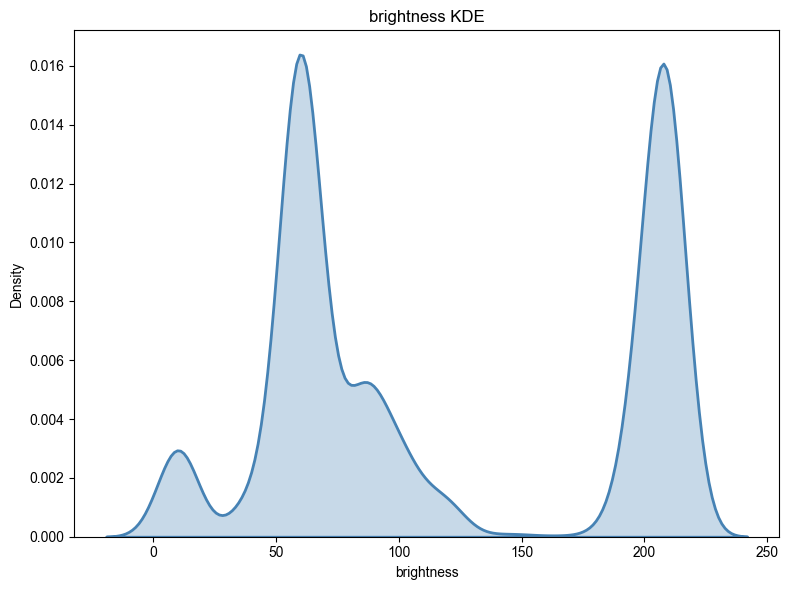

,brightness
count,56920.000000
mean,118.326710
std,72.037515
min,4.940000
25%,59.640000
50%,86.320000
75%,206.830000
max,217.710000


In [5]:
frame_df = pd.read_csv(CONVERSION_ROOT / "frame_stats.csv")

kde_plot(df=frame_df, figsize=(8, 6), col='brightness', show=True) # 밝기
frame_df[['brightness']].describe()

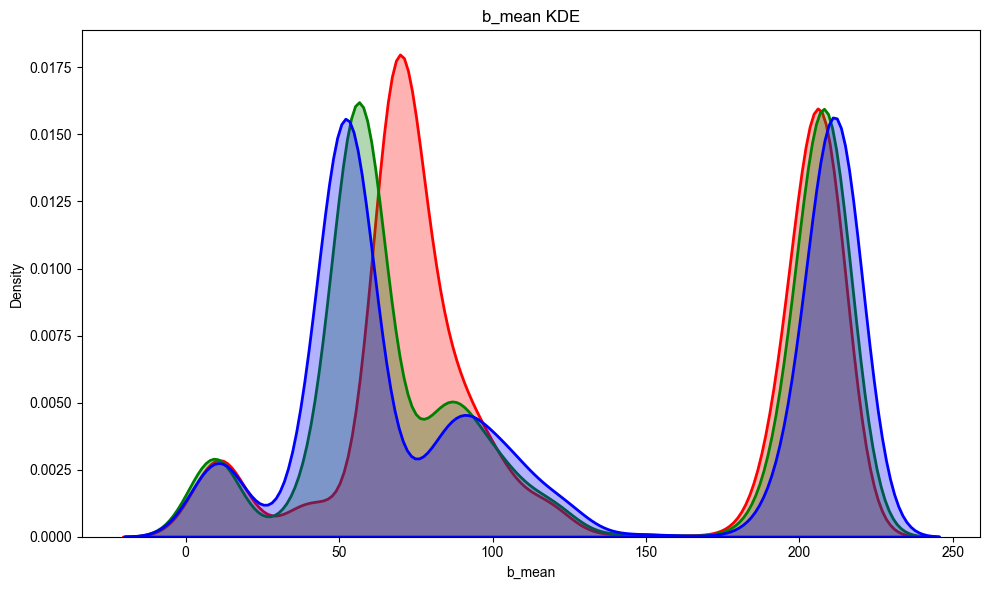

,r_mean,g_mean,b_mean
count,56920.000000,56920.000000,56920.000000
mean,120.695278,117.195737,117.879067
std,68.728625,73.157339,75.572294
min,2.610000,4.720000,5.390000
25%,68.657500,56.410000,52.250000
50%,85.990000,86.220000,89.040000
75%,204.850000,207.010000,210.420000
max,216.870000,217.660000,220.140000


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for col, color in zip(['r_mean', 'g_mean', 'b_mean'], ['red', 'green', 'blue']):
    kde_plot(df=frame_df, col=col, color=color, ax=ax, show=False)
plt.tight_layout()
plt.show()

frame_df[['r_mean',	'g_mean', 'b_mean']].describe()